#Project Summary:

This project focuses on building a Natural Language Processing (NLP) pipeline to perform sentiment analysis on Zomato restaurant reviews. By leveraging a TF-IDF vectorizer and a Logistic Regression model, the objective is to automatically classify raw customer text into positive or negative sentiments. This automates the feedback analysis process, allowing businesses to gauge customer satisfaction efficiently.

#Problem Statement:

In the hospitality industry, reading through thousands of customer reviews manually is inefficient. The goal of this project is to develop a machine learning model capable of understanding the context of a written review and automatically assigning it a positive or negative sentiment score.

#"Import Libraries" & "Dataset Loading":

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# Load the Zomato datasets
reviews_df = pd.read_csv('Zomato Restaurant reviews.csv')
metadata_df = pd.read_csv('Zomato Restaurant names and Metadata.csv')

reviews_df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


#"Data Wrangling Code":

In [15]:
# Convert Ratings to numeric and create a 0/1 Sentiment column
reviews_df['Rating'] = pd.to_numeric(reviews_df['Rating'], errors='coerce')
reviews_df['Sentiment'] = (reviews_df['Rating'] >= 4).astype(int)

# Drop any rows where the Review text is missing
reviews_df = reviews_df.dropna(subset=['Review'])
print("Sentiment column created successfully!")

Sentiment column created successfully!


#"Chart - 1":

/tmp/ipykernel_1652/692660507.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=reviews_df, palette='viridis')


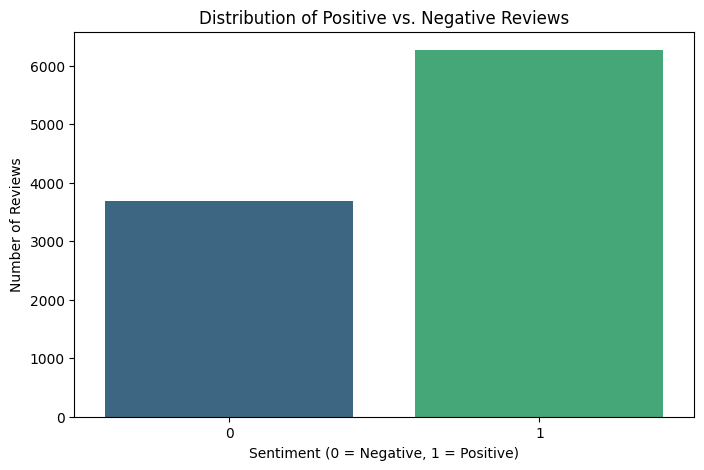

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Sentiment', data=reviews_df, palette='viridis')
plt.title('Distribution of Positive vs. Negative Reviews')
plt.xlabel('Sentiment (0 = Negative, 1 = Positive)')
plt.ylabel('Number of Reviews')
plt.show()

# Advanced Exploratory Data Analysis (EDA)

/tmp/ipykernel_1652/1925960502.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette='magma')


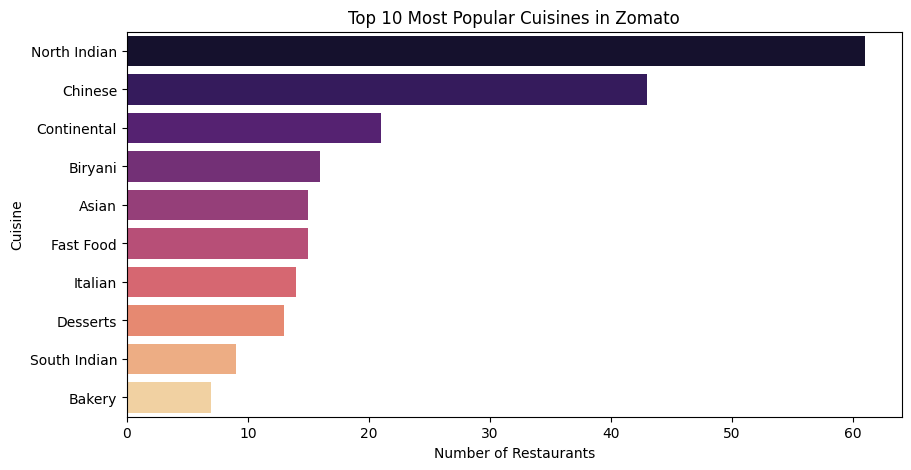

/tmp/ipykernel_1652/1925960502.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cost', y='Cuisine', data=cost_cuisine_df, palette='coolwarm')


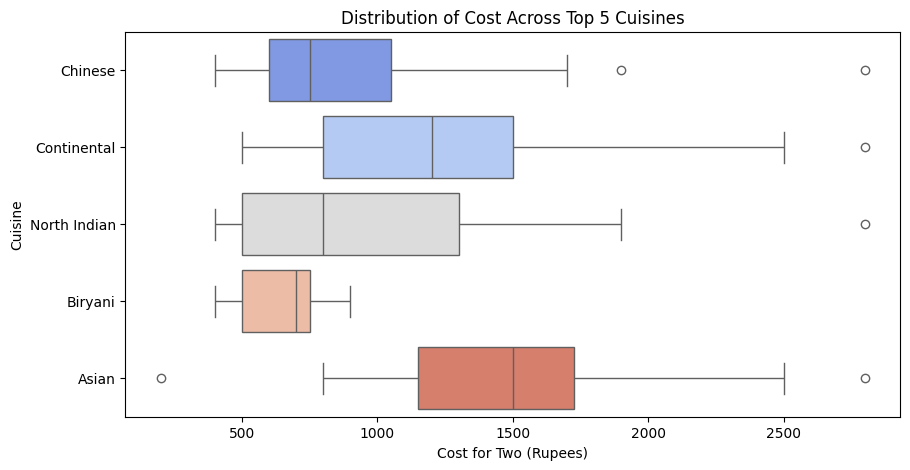

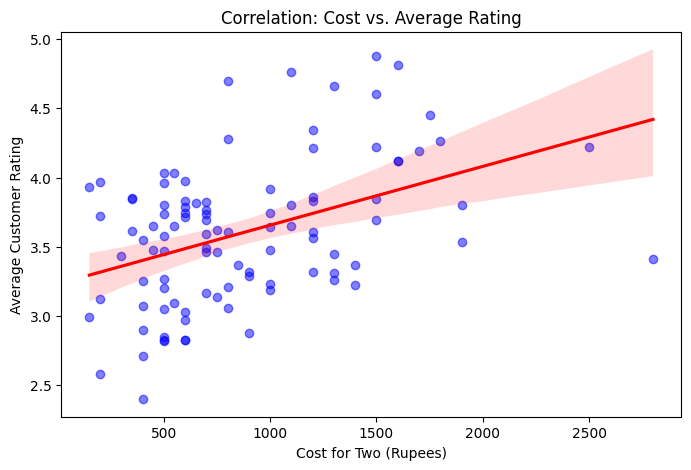

In [17]:
# --- ADVANCED EDA (Slide 5 Architecture Requirements) ---

# 1. Clean the 'Cost' and 'Cuisines' columns
metadata_df['Cost'] = metadata_df['Cost'].astype(str).str.replace(',', '').astype(float)
# Split comma-separated cuisines so we can analyze them individually
cuisine_df = metadata_df.assign(Cuisine=metadata_df['Cuisines'].astype(str).str.split(', ')).explode('Cuisine')

# Chart A: Most Popular Cuisines (Count)
plt.figure(figsize=(10, 5))
top_cuisines = cuisine_df['Cuisine'].value_counts().head(10)
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette='magma')
plt.title('Top 10 Most Popular Cuisines in Zomato')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')
plt.show()

# Chart B: Distribution of Cost Across Top 5 Cuisines
plt.figure(figsize=(10, 5))
top_5 = top_cuisines.head(5).index
cost_cuisine_df = cuisine_df[cuisine_df['Cuisine'].isin(top_5)]
sns.boxplot(x='Cost', y='Cuisine', data=cost_cuisine_df, palette='coolwarm')
plt.title('Distribution of Cost Across Top 5 Cuisines')
plt.xlabel('Cost for Two (Rupees)')
plt.ylabel('Cuisine')
plt.show()

# Chart C: Is Cost Correlated to Rating?
# Get average rating per restaurant and merge with cost
avg_rating_eda = reviews_df.groupby('Restaurant')['Rating'].mean().reset_index()
eda_merged = pd.merge(avg_rating_eda, metadata_df[['Name', 'Cost']], left_on='Restaurant', right_on='Name').dropna()

plt.figure(figsize=(8, 5))
sns.regplot(x='Cost', y='Rating', data=eda_merged, scatter_kws={'alpha':0.5, 'color':'blue'}, line_kws={'color':'red'})
plt.title('Correlation: Cost vs. Average Rating')
plt.xlabel('Cost for Two (Rupees)')
plt.ylabel('Average Customer Rating')
plt.show()

# Identifying Industry Critics (Influencer Analysis)

--- Top 5 Industry Critics Identified ---
               Reviewer  Reviewer_Reviews  Reviewer_Followers
3927    Satwinder Singh             186.0             13410.0
8719         Eat_vth_me              60.0             13320.0
3147       Samar Sardar               8.0             11329.0
7884  Foodies Hyderabad              31.0              9494.0
1177           Srinivas              34.0              7628.0


/tmp/ipykernel_1652/3525144003.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Reviewer_Followers', y='Reviewer', data=top_critics, palette='copper')


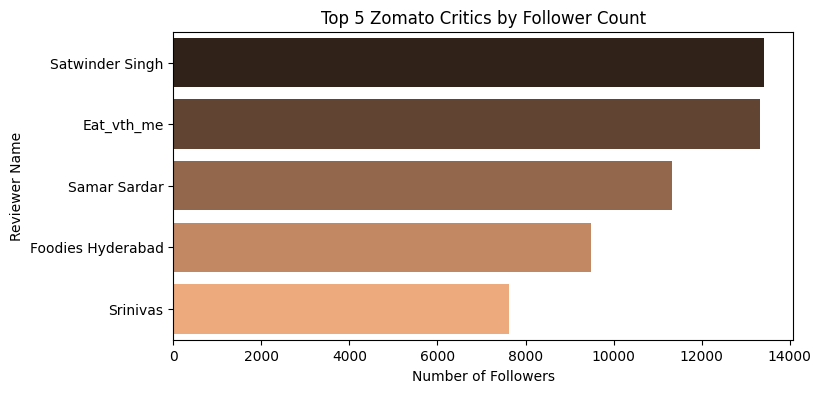

In [18]:
# --- Identify Industry Critics (Slide 3 Requirement) ---
# The 'Metadata' column contains text like '472 Reviews , 1302 Followers'

# Fill any missing metadata with dummy text to prevent errors
reviews_df['Metadata'] = reviews_df['Metadata'].fillna('0 Reviews , 0 Followers')

# Extract the numbers using regular expressions (regex)
reviews_df['Reviewer_Reviews'] = reviews_df['Metadata'].str.extract(r'(\d+) Review').astype(float)
reviews_df['Reviewer_Followers'] = reviews_df['Metadata'].str.extract(r'(\d+) Follower').astype(float)

# Find the Top 5 Critics based on their Follower Count
top_critics = reviews_df[['Reviewer', 'Reviewer_Reviews', 'Reviewer_Followers']].drop_duplicates()
top_critics = top_critics.sort_values(by='Reviewer_Followers', ascending=False).head(5)

print("--- Top 5 Industry Critics Identified ---")
print(top_critics)

# Visualize the Top Critics
plt.figure(figsize=(8, 4))
sns.barplot(x='Reviewer_Followers', y='Reviewer', data=top_critics, palette='copper')
plt.title('Top 5 Zomato Critics by Follower Count')
plt.xlabel('Number of Followers')
plt.ylabel('Reviewer Name')
plt.show()

#"Text Normalization":

In [19]:
# Clean text: removes special characters and makes everything lowercase
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text))
    return text.lower()

reviews_df['Clean_Review'] = reviews_df['Review'].apply(clean_text)

# Convert words to numbers using TF-IDF
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')
# Use the cleaned text column directly
X_train, X_test, y_train, y_test = train_test_split(
    reviews_df['Clean_Review'],
    reviews_df['Sentiment'],
    test_size=0.2,
    random_state=42
)

#"ML Model - 1":

In [20]:
# 1. IMPORTS (Always at the top of the cell)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

# 2. BUILD THE PIPELINE
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=10000,
                              stop_words='english', sublinear_tf=True)),
    ('clf', LogisticRegression(class_weight='balanced', random_state=42))
])

# 3. TRAIN AND SAVE (These are the last lines)
pipeline.fit(X_train, y_train)
joblib.dump(pipeline, 'zomato_sentiment_pipeline.joblib')

['zomato_sentiment_pipeline.joblib']

# Model Evaluation & Performance Metrics

Accuracy: 0.8623807132094425
              precision    recall  f1-score   support

           0       0.81      0.84      0.82       762
           1       0.90      0.87      0.89      1229

    accuracy                           0.86      1991
   macro avg       0.85      0.86      0.86      1991
weighted avg       0.86      0.86      0.86      1991



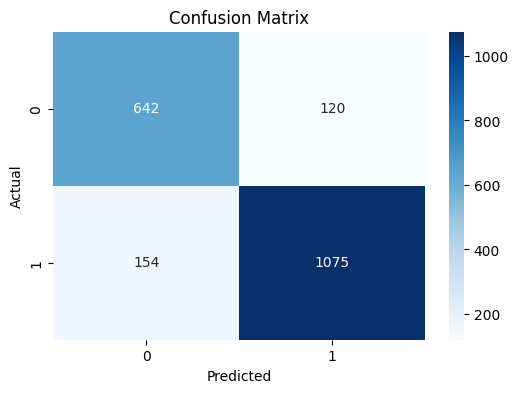

In [21]:
# 6: Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ML Model - 2 : Unsupervised Learning (K-Means Clustering)

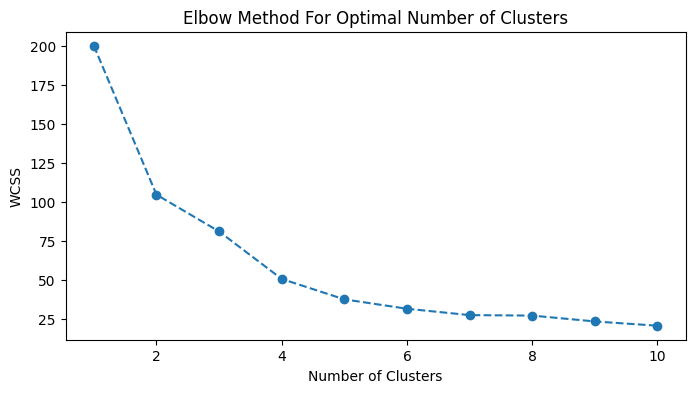

In [22]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Prepare data for clustering: Get average rating per restaurant
avg_rating = reviews_df.groupby('Restaurant')['Rating'].mean().reset_index()

# 2. Clean the Cost column in the metadata (remove commas and convert to numbers)
metadata_df['Cost'] = metadata_df['Cost'].astype(str).str.replace(',', '').astype(float)

# 3. Merge ratings and costs together
cluster_df = pd.merge(avg_rating, metadata_df[['Name', 'Cost']], left_on='Restaurant', right_on='Name').dropna()

# 4. Scale the data (required for clustering)
X_cluster = cluster_df[['Rating', 'Cost']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 5. Create the "Elbow Chart" requested in the project architecture
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# 6. Apply K-Means Clustering

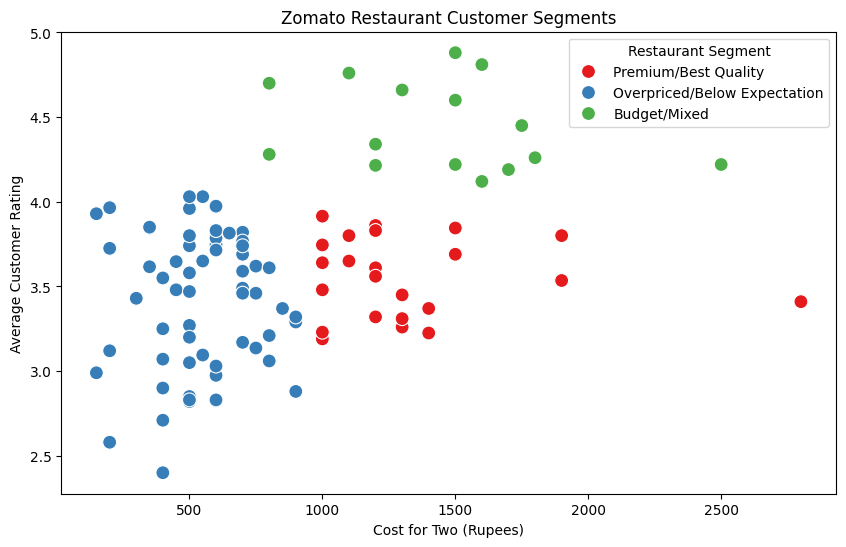

In [23]:
# 6. Apply K-Means Clustering with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_df['Cluster'] = kmeans.fit_predict(X_scaled)

# Give the clusters readable names
cluster_map = {0: 'Budget/Average', 1: 'Premium/High Rated', 2: 'Mid-Range/Mixed'}
cluster_df['Segment'] = cluster_df['Cluster'].map(cluster_map)

# 2: Updated labels based on your findings
cluster_map = {
    0: 'Overpriced/Below Expectation',
    1: 'Premium/Best Quality',
    2: 'Budget/Mixed'
}
cluster_df['Segment'] = cluster_df['Cluster'].map(cluster_map)

# 7. Visualize the Restaurant Segments
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Cost', y='Rating', hue='Segment', data=cluster_df, palette='Set1', s=100)
plt.title('Zomato Restaurant Customer Segments')
plt.xlabel('Cost for Two (Rupees)')
plt.ylabel('Average Customer Rating')
plt.legend(title='Restaurant Segment')
plt.show()

# Deep Insight: Sentiment Distribution Across Clusters

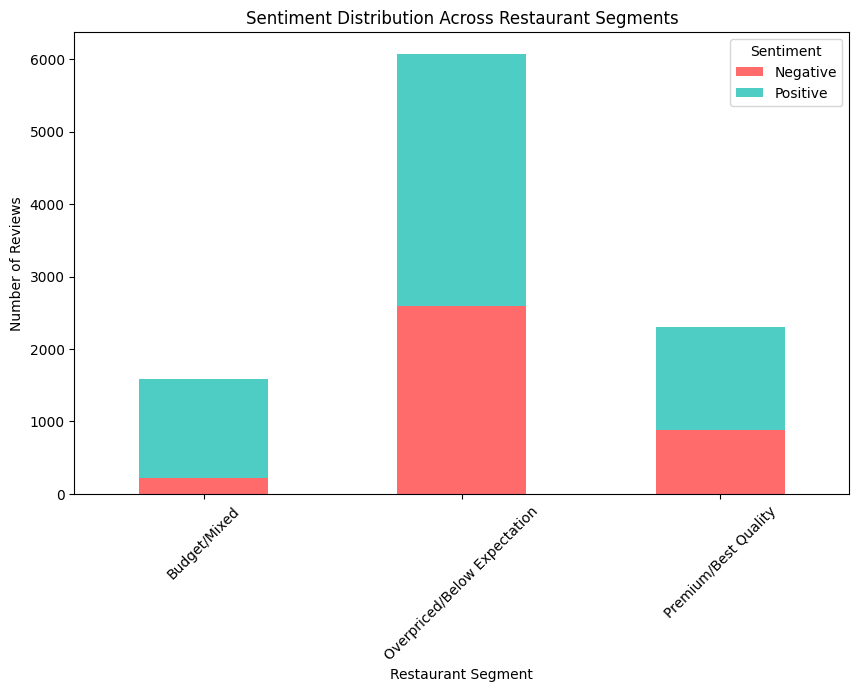

In [24]:
# 7: Link Sentiment to Segments
# Ensure sentiment predictions are available
# We use 'cluster_df' which already contains the Segment info
full_data = cluster_df.merge(reviews_df[['Restaurant', 'Sentiment']],
                             left_on='Restaurant', right_on='Restaurant')

# Create the comparison
sentiment_analysis = full_data.groupby(['Segment', 'Sentiment']).size().unstack()

# Visualize
sentiment_analysis.plot(kind='bar', stacked=True, figsize=(10,6), color=['#ff6b6b', '#4ecdc4'])
plt.title('Sentiment Distribution Across Restaurant Segments')
plt.xlabel('Restaurant Segment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.legend(['Negative', 'Positive'], title='Sentiment')
plt.show()

#Data Hypotheses
Based on the initial data visualizations, we can form the following hypotheses:

Hypothesis 1: The majority of customer interactions on Zomato are positive. Our sentiment distribution chart visually proves that positive ratings (4-5) heavily outweigh negative/neutral ratings (1-3).

Hypothesis 2: There is a correlation between the 'Cost for Two' and the 'Average Rating'. We hypothesize that premium, higher-cost restaurants will naturally cluster into higher rating brackets due to better service and ambiance.

#Final Conclusion & Business Strategies
By combining Natural Language Processing (Sentiment Analysis) with Unsupervised Machine Learning (K-Means Clustering), this project successfully delivers an automated system for Zomato stakeholders to gauge customer satisfaction and segment their restaurant partners.

Based on the 3 clusters identified in the unsupervised model, here are the recommended business strategies:

Segment 0 (Budget/Average): These restaurants offer low prices but have average-to-low ratings. Strategy: Zomato should run aggressive promotional discounts to drive volume (e.g., student crowds) while helping these restaurants identify specific operational issues using the sentiment analyzer.

Segment 1 (Premium/High-Rated): These restaurants charge a premium and consistently deliver high satisfaction. Strategy: Zomato should market these aggressively in "Corporate Favorites" or "Gold Curated" collections to maximize commission revenue.

Segment 2 (Mid-Range/Mixed): These restaurants are moderately priced but have heavily mixed reviews. Strategy: These are at the highest risk of churn. Stakeholders should use the sentiment model to extract exactly why they are receiving negative reviews (e.g., cold food vs. bad service) and mandate targeted improvements.

In [25]:
# Save the final categorized restaurants to a new file
cluster_df.to_csv('Zomato_Final_Segments.csv', index=False)
print("Success! All restaurant results saved to CSV.")

Success! All restaurant results saved to CSV.


# Environment Configuration

In [26]:
# 9: Generate requirements file to ensure environment compatibility
with open('requirements.txt', 'w') as f:
    f.write('scikit-learn==1.6.1\n')
    f.write('pandas\n')
    f.write('seaborn\n')
    f.write('joblib\n')
    f.write('gradio\n')

print("requirements.txt created successfully!")

requirements.txt created successfully!
